# **CHATKASIR - Data Analysis & Dashboard**

Author    : Salman Pandu Pandiya (DS-2)

Deskripsi : Pendefinisian 5-7 pertanyaan bisnis terukur dan eksplorasi       awal dataset makanan serta variasi format data sintetis.

## **Setup & Import Library**

In [1]:
# ============================================================
# BLOK 0: SETUP & IMPORT LIBRARY
# Jalankan blok ini pertama kali sebelum blok lainnya
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import random
import re
import warnings
from collections import Counter

warnings.filterwarnings('ignore')

# --- Konfigurasi gaya visual global ---
# Pakai satu palet warna konsisten di seluruh notebook
PALETTE      = "Set2"
PRIMARY_COLOR = "#2ECC71"   # hijau → merek ChatKasir
ACCENT_COLOR  = "#E74C3C"   # merah untuk highlight
BG_COLOR      = "#F9F9F9"

plt.rcParams.update({
    "figure.facecolor": BG_COLOR,
    "axes.facecolor"  : BG_COLOR,
    "axes.titlesize"  : 14,
    "axes.labelsize"  : 11,
    "xtick.labelsize" : 9,
    "ytick.labelsize" : 9,
    "legend.fontsize" : 9,
    "figure.dpi"      : 120,
})

print("✅ Setup selesai. Library siap digunakan.")

✅ Setup selesai. Library siap digunakan.


## **Perumusan Masalah (Business Questions)**

In [2]:
# ============================================================
# BLOK 1: PERUMUSAN MASALAH
# Mendefinisikan 6 pertanyaan bisnis terukur untuk dashboard
# penjual UMKM ChatKasir.
# ============================================================

pertanyaan_bisnis = {
    "BQ-1": {
        "pertanyaan": "Produk apa saja yang paling sering dipesan pelanggan?",
        "metrik"    : "Frekuensi kemunculan nama produk dalam data transaksi",
        "kegunaan"  : "Penjual tahu produk andalan untuk diprioritaskan stoknya",
    },
    "BQ-2": {
        "pertanyaan": "Berapa rata-rata nilai transaksi per pesanan?",
        "metrik"    : "Mean & median total harga per sesi obrolan",
        "kegunaan"  : "Acuan target omset harian / bulanan yang realistis",
    },
    "BQ-3": {
        "pertanyaan": "Bagaimana distribusi harga produk yang dijual?",
        "metrik"    : "Histogram harga; segmentasi murah/sedang/premium",
        "kegunaan"  : "Penjual dapat mengevaluasi strategi penetapan harga",
    },
    "BQ-4": {
        "pertanyaan": "Berapa jumlah item yang biasanya dipesan dalam satu transaksi?",
        "metrik"    : "Distribusi quantity per transaksi",
        "kegunaan"  : "Dasar penentuan minimum order & penawaran bundling",
    },
    "BQ-5": {
        "pertanyaan": "Kata slang atau singkatan apa yang paling sering muncul dalam chat pesanan?",
        "metrik"    : "Frekuensi kata slang; peta normalisasi ke kata formal",
        "kegunaan"  : "Prioritas kamus normalisasi untuk akurasi model NLP",
    },
    "BQ-6": {
        "pertanyaan": "Kategori produk makanan apa yang paling banyak tersedia di katalog?",
        "metrik"    : "Frekuensi kata kunci kategori pada nama produk",
        "kegunaan"  : "Petakan cakupan katalog & potensi gap produk",
    },
}

# --- Tampilkan ringkasan ---
print("=" * 65)
print("  PERTANYAAN BISNIS — ChatKasir UMKM Dashboard")
print("=" * 65)
for kode, detail in pertanyaan_bisnis.items():
    print(f"\n🔹 {kode}: {detail['pertanyaan']}")
    print(f"   📊 Metrik  : {detail['metrik']}")
    print(f"   💡 Kegunaan: {detail['kegunaan']}")
print("\n✅ 6 pertanyaan bisnis terdefinisi dengan baik.")

  PERTANYAAN BISNIS — ChatKasir UMKM Dashboard

🔹 BQ-1: Produk apa saja yang paling sering dipesan pelanggan?
   📊 Metrik  : Frekuensi kemunculan nama produk dalam data transaksi
   💡 Kegunaan: Penjual tahu produk andalan untuk diprioritaskan stoknya

🔹 BQ-2: Berapa rata-rata nilai transaksi per pesanan?
   📊 Metrik  : Mean & median total harga per sesi obrolan
   💡 Kegunaan: Acuan target omset harian / bulanan yang realistis

🔹 BQ-3: Bagaimana distribusi harga produk yang dijual?
   📊 Metrik  : Histogram harga; segmentasi murah/sedang/premium
   💡 Kegunaan: Penjual dapat mengevaluasi strategi penetapan harga

🔹 BQ-4: Berapa jumlah item yang biasanya dipesan dalam satu transaksi?
   📊 Metrik  : Distribusi quantity per transaksi
   💡 Kegunaan: Dasar penentuan minimum order & penawaran bundling

🔹 BQ-5: Kata slang atau singkatan apa yang paling sering muncul dalam chat pesanan?
   📊 Metrik  : Frekuensi kata slang; peta normalisasi ke kata formal
   💡 Kegunaan: Prioritas kamus normalisasi

# **CHATKASIR - Data Analysis & Dashboard**

Author    : Salman Pandu Pandiya (DS-2)

Deskripsi : EDA dataset makanan, slang, dan sintetis. Memetakan distribusi kategori, tren harga, dan anomali kata slang.

## **EDA Dataset Makanan**

=== INFO DATASET MAKANAN ===
Jumlah baris  : 18,558
Jumlah kolom  : 1
Nama kolom    : ['name']

Sampel 5 baris pertama:
                 name
0                abon
1           abon ayam
2         abon burger
3  abon cheese burger
4    abon goreng ayam

--- Cek Kualitas Data ---
Nilai null   : 0
Duplikat     : 0
Baris setelah cleaning: 18,558

--- Statistik Panjang Nama Produk ---
       panjang_nama  jumlah_kata
count      18558.00     18558.00
mean          16.95         2.83
std            5.96         0.94
min            2.00         1.00
25%           12.00         2.00
50%           17.00         3.00
75%           21.00         3.00
max           52.00         5.00

--- Distribusi Kategori Produk ---
kategori
Lainnya    11848
Minuman     1386
Kopi        1020
Ayam         937
Nasi         909
Mie          711
Seafood      643
Sapi         531
Kue          463
Sayur        110
Name: count, dtype: int64


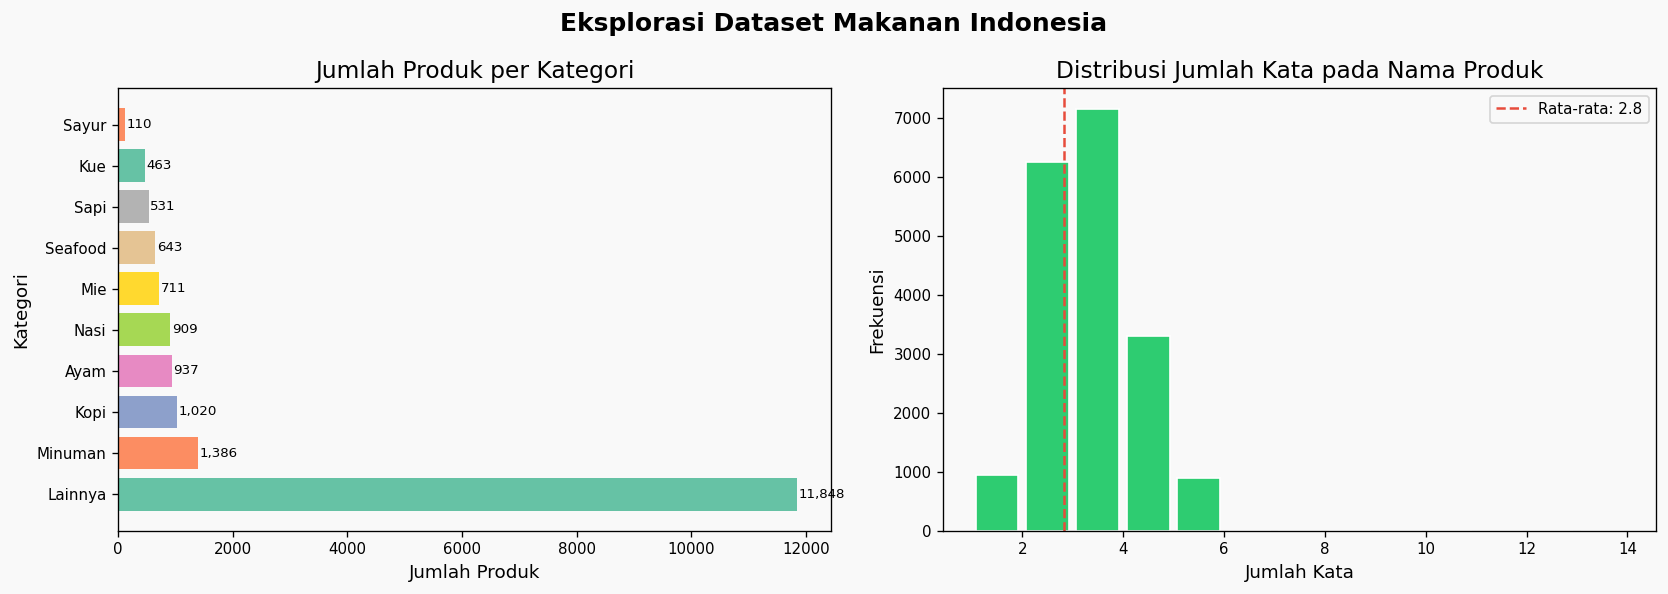

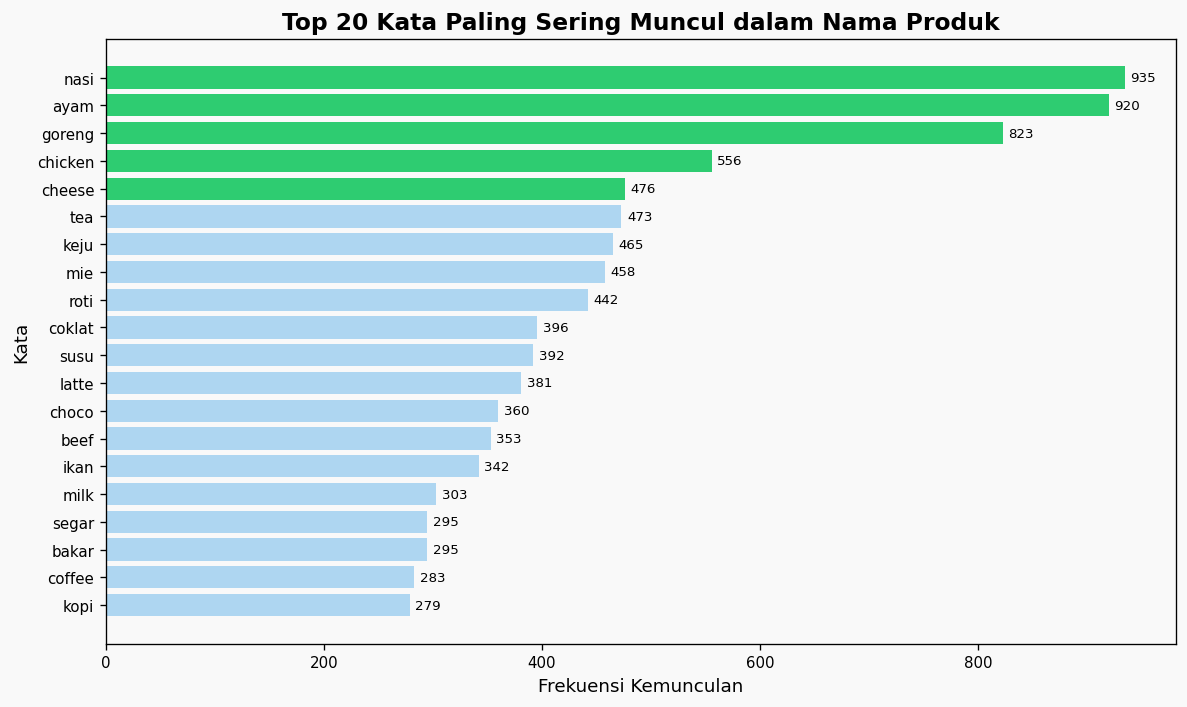


✅ EDA Dataset Makanan selesai.


In [3]:
# ============================================================
# BLOK 2: EDA DATASET MAKANAN (food_utama.csv)
# Eksplorasi distribusi produk makanan Indonesia
# ============================================================

# --- 2A. Load Data ---
df_food = pd.read_csv("food_utama (1).csv")  # sesuaikan path jika perlu

print("=== INFO DATASET MAKANAN ===")
print(f"Jumlah baris  : {len(df_food):,}")
print(f"Jumlah kolom  : {df_food.shape[1]}")
print(f"Nama kolom    : {df_food.columns.tolist()}")
print(f"\nSampel 5 baris pertama:")
print(df_food.head())

# --- 2B. Cek nilai kosong & duplikat ---
print("\n--- Cek Kualitas Data ---")
print(f"Nilai null   : {df_food['name'].isnull().sum()}")
print(f"Duplikat     : {df_food['name'].duplicated().sum()}")

# Hapus duplikat & null untuk analisis bersih
df_food_clean = (
    df_food
    .dropna(subset=["name"])
    .drop_duplicates(subset=["name"])
    .reset_index(drop=True)
)
df_food_clean["name"] = df_food_clean["name"].str.strip().str.lower()
print(f"Baris setelah cleaning: {len(df_food_clean):,}")

# --- 2C. Analisis Panjang Nama Produk ---
df_food_clean["panjang_nama"] = df_food_clean["name"].str.len()
df_food_clean["jumlah_kata"]  = df_food_clean["name"].str.split().str.len()

print("\n--- Statistik Panjang Nama Produk ---")
print(df_food_clean[["panjang_nama", "jumlah_kata"]].describe().round(2))

# --- 2D. Ekstrak Kata Kunci Kategori dari Nama Produk ---
# Karena tidak ada kolom kategori, kita buat kategori dari kata kunci
kategori_keyword = {
    "Ayam"    : ["ayam"],
    "Kopi"    : ["kopi", "coffee", "latte", "espresso", "americano", "cappuccino"],
    "Minuman" : ["juice", "jus", "teh", "tea", "milk", "milkshake", "soda", "air"],
    "Nasi"    : ["nasi", "rice"],
    "Mie"     : ["mie", "mifan", "ramen", "udon", "soba", "kwetiau"],
    "Kue"     : ["kue", "cake", "cookies", "donut", "pastry", "croissant"],
    "Seafood" : ["ikan", "udang", "cumi", "kepiting", "kerang", "lobster"],
    "Sapi"    : ["sapi", "beef", "steak", "daging"],
    "Sayur"   : ["sayur", "vegetable", "vege", "salad"],
    "Lainnya" : [],
}

def cari_kategori(nama):
    """Fungsi sederhana mencocokkan kata kunci kategori pada nama produk."""
    for kat, keywords in kategori_keyword.items():
        if kat == "Lainnya":
            continue
        for kw in keywords:
            if kw in nama:
                return kat
    return "Lainnya"

df_food_clean["kategori"] = df_food_clean["name"].apply(cari_kategori)

print("\n--- Distribusi Kategori Produk ---")
print(df_food_clean["kategori"].value_counts())

# --- 2E. VISUALISASI 1: Distribusi per Kategori ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Eksplorasi Dataset Makanan Indonesia", fontsize=15, fontweight="bold")

# Bar chart kategori
cat_counts = df_food_clean["kategori"].value_counts()
axes[0].barh(cat_counts.index, cat_counts.values,
             color=sns.color_palette(PALETTE, len(cat_counts)))
axes[0].set_title("Jumlah Produk per Kategori")
axes[0].set_xlabel("Jumlah Produk")
axes[0].set_ylabel("Kategori")
for i, (val) in enumerate(cat_counts.values):
    axes[0].text(val + 30, i, f"{val:,}", va="center", fontsize=8)

# Histogram jumlah kata pada nama produk
axes[1].hist(df_food_clean["jumlah_kata"], bins=range(1, 15),
             color=PRIMARY_COLOR, edgecolor="white", rwidth=0.85)
axes[1].set_title("Distribusi Jumlah Kata pada Nama Produk")
axes[1].set_xlabel("Jumlah Kata")
axes[1].set_ylabel("Frekuensi")
axes[1].axvline(df_food_clean["jumlah_kata"].mean(), color=ACCENT_COLOR,
                linestyle="--", label=f"Rata-rata: {df_food_clean['jumlah_kata'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_food_overview.png", bbox_inches="tight")
plt.show()

# --- 2F. VISUALISASI 2: Top 20 Kata yang Paling Sering Muncul dalam Nama Produk ---
# Pecah semua nama menjadi kata-kata individual
semua_kata = " ".join(df_food_clean["name"]).split()
# Filter kata umum yang tidak informatif (stopwords sederhana)
stopwords = {"dan", "de", "with", "or", "of", "the", "in", "a", "an", "for",
             "ice", "hot", "large", "medium", "small", "regular", "mini",
             "original", "special", "extra", "super"}
kata_bersih = [k for k in semua_kata if k not in stopwords and len(k) > 2]
top_kata = Counter(kata_bersih).most_common(20)

fig, ax = plt.subplots(figsize=(10, 6))
kata_list, frek_list = zip(*top_kata)
colors = [PRIMARY_COLOR if i < 5 else "#AED6F1" for i in range(len(kata_list))]
bars = ax.barh(kata_list[::-1], frek_list[::-1], color=colors[::-1])
ax.set_title("Top 20 Kata Paling Sering Muncul dalam Nama Produk", fontweight="bold")
ax.set_xlabel("Frekuensi Kemunculan")
ax.set_ylabel("Kata")
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("eda_food_top_kata.png", bbox_inches="tight")
plt.show()

print("\n✅ EDA Dataset Makanan selesai.")

## **EDA Dataset Slang**



=== INFO DATASET SLANG ===
Jumlah entri: 1,231
Kolom       : ['slang', 'formal']

Sampel 10 baris pertama:
      slang    formal
0        aa     kakak
1   abanggg     abang
2  abanggku   abangku
3    abeees     habis
4      abes     habis
5      abez     habis
6       abg     abang
7    abgnya  abangnya
8  abgnyaah  abangnya
9     abiez     habis

--- Cek Kualitas Data ---
slang     0
formal    0
dtype: int64
Duplikat slang: 0

--- Statistik Panjang Kata Slang vs Formal ---
       panjang_slang  panjang_formal  selisih_panjang
count        1231.00         1231.00          1231.00
mean            6.29            8.00             1.71
std             2.96            4.55             4.10
min             1.00            3.00           -14.00
25%             4.00            5.00             0.00
50%             6.00            7.00             1.00
75%             8.00           10.00             2.00
max            20.00           34.00            31.00

--- Kata Formal dengan Paling Bany

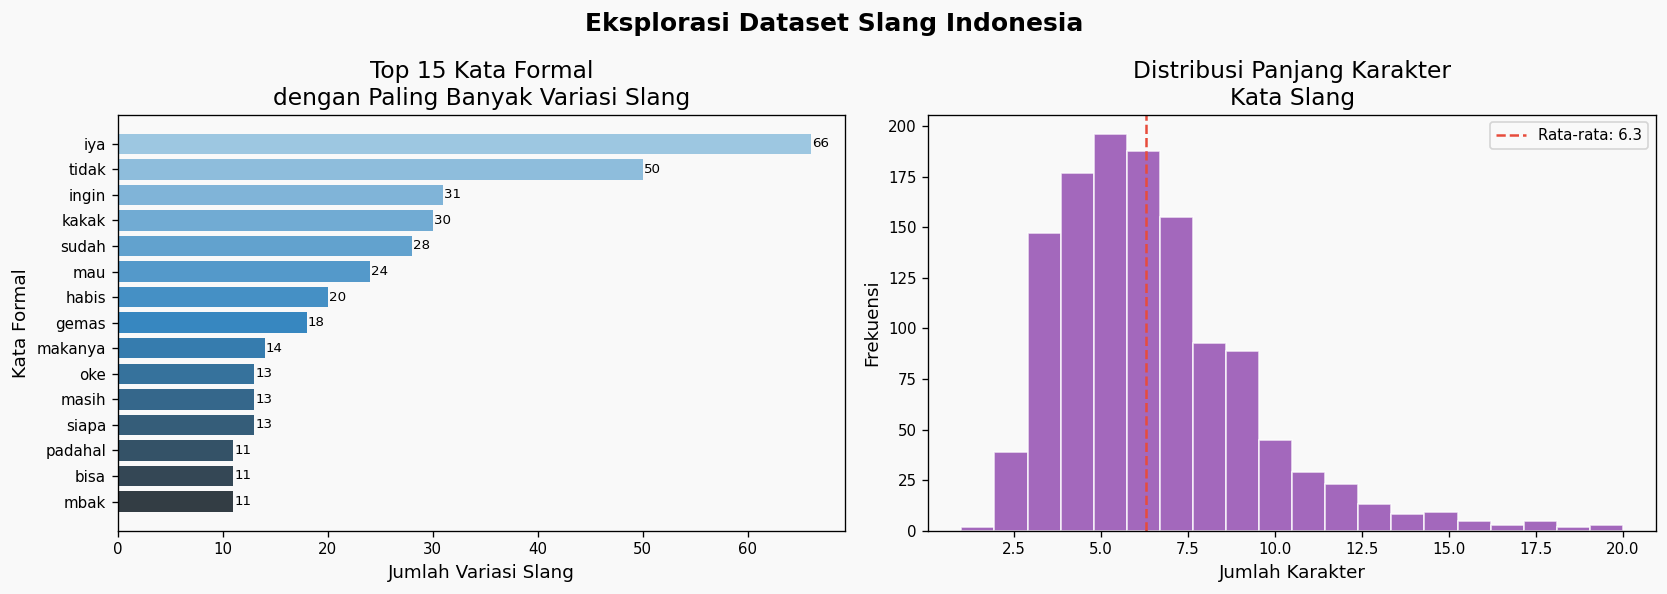

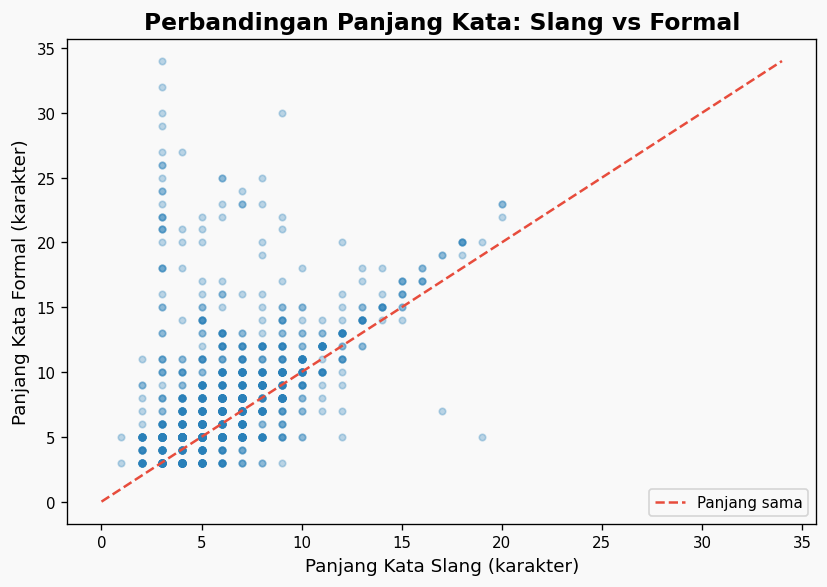


✅ EDA Dataset Slang selesai.


In [4]:
# ============================================================
# BLOK 3: EDA DATASET SLANG (slang_utama.csv)
# Analisis kamus kata gaul yang digunakan dalam chat pesanan
# ============================================================

# --- 3A. Load Data ---
df_slang = pd.read_csv("slang_utama (1).csv")

print("=== INFO DATASET SLANG ===")
print(f"Jumlah entri: {len(df_slang):,}")
print(f"Kolom       : {df_slang.columns.tolist()}")
print(f"\nSampel 10 baris pertama:")
print(df_slang.head(10))

# --- 3B. Cek kualitas data ---
print("\n--- Cek Kualitas Data ---")
print(df_slang.isnull().sum())
print(f"Duplikat slang: {df_slang['slang'].duplicated().sum()}")

df_slang_clean = (
    df_slang
    .dropna()
    .drop_duplicates(subset=["slang"])
    .reset_index(drop=True)
)
df_slang_clean["slang"]  = df_slang_clean["slang"].str.strip().str.lower()
df_slang_clean["formal"] = df_slang_clean["formal"].str.strip().str.lower()

# --- 3C. Analisis Panjang Kata Slang ---
df_slang_clean["panjang_slang"]  = df_slang_clean["slang"].str.len()
df_slang_clean["panjang_formal"] = df_slang_clean["formal"].str.len()
df_slang_clean["selisih_panjang"] = (
    df_slang_clean["panjang_formal"] - df_slang_clean["panjang_slang"]
)

print("\n--- Statistik Panjang Kata Slang vs Formal ---")
print(df_slang_clean[["panjang_slang", "panjang_formal", "selisih_panjang"]].describe().round(2))

# --- 3D. Temukan kata formal yang PALING banyak versi slang-nya ---
# Ini berguna: kata yang paling banyak variasinya = paling butuh normalisasi
top_formal = df_slang_clean["formal"].value_counts().head(15)
print("\n--- Kata Formal dengan Paling Banyak Variasi Slang ---")
print(top_formal)

# --- 3E. VISUALISASI 1: Top 15 Kata Formal Paling Banyak Variasi ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Eksplorasi Dataset Slang Indonesia", fontsize=15, fontweight="bold")

axes[0].barh(top_formal.index[::-1], top_formal.values[::-1],
             color=sns.color_palette("Blues_d", len(top_formal))[::-1])
axes[0].set_title("Top 15 Kata Formal\ndengan Paling Banyak Variasi Slang")
axes[0].set_xlabel("Jumlah Variasi Slang")
axes[0].set_ylabel("Kata Formal")
for i, v in enumerate(top_formal.values[::-1]):
    axes[0].text(v + 0.1, i, str(v), va="center", fontsize=8)

# Distribusi panjang kata slang
axes[1].hist(df_slang_clean["panjang_slang"], bins=20,
             color="#8E44AD", edgecolor="white", alpha=0.8)
axes[1].set_title("Distribusi Panjang Karakter\nKata Slang")
axes[1].set_xlabel("Jumlah Karakter")
axes[1].set_ylabel("Frekuensi")
axes[1].axvline(df_slang_clean["panjang_slang"].mean(), color=ACCENT_COLOR,
                linestyle="--",
                label=f"Rata-rata: {df_slang_clean['panjang_slang'].mean():.1f}")
axes[1].legend()

plt.tight_layout()
plt.savefig("eda_slang_overview.png", bbox_inches="tight")
plt.show()

# --- 3F. VISUALISASI 2: Scatter Panjang Slang vs Formal ---
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(df_slang_clean["panjang_slang"], df_slang_clean["panjang_formal"],
           alpha=0.3, color="#2980B9", s=15)
# Garis y=x (jika slang == formal panjangnya)
max_val = max(df_slang_clean["panjang_formal"].max(),
              df_slang_clean["panjang_slang"].max())
ax.plot([0, max_val], [0, max_val], color=ACCENT_COLOR,
        linestyle="--", label="Panjang sama")
ax.set_title("Perbandingan Panjang Kata: Slang vs Formal", fontweight="bold")
ax.set_xlabel("Panjang Kata Slang (karakter)")
ax.set_ylabel("Panjang Kata Formal (karakter)")
ax.legend()
plt.tight_layout()
plt.savefig("eda_slang_scatter.png", bbox_inches="tight")
plt.show()

print("\n✅ EDA Dataset Slang selesai.")

## **Buat & EDA Data Sintetis**

=== INFO DATA SINTETIS ===
Jumlah transaksi: 1,000
  id_transaksi                                          teks_chat  \
0     TRX-0001         order 1 chili doc donk, bayar rp 75rb donk   
1     TRX-0002  pesen 3 huzzelnut milk coffee ya kak, 433.500 ...   
2     TRX-0003   tolong pesankan 1 iga penyet nasi, harga rp 11rb   
3     TRX-0004             hokkaido choco 2 pcs harga 122k ya min   
4     TRX-0005           pesan teh tarik cold 3 harga 136.500 dlu   

             nama_produk  qty  harga_satuan  total_harga  
0              chili doc    1         75000        75000  
1  huzzelnut milk coffee    3        144500       433500  
2        iga penyet nasi    1         11500        11500  
3         hokkaido choco    2         61000       122000  
4         teh tarik cold    3         45500       136500  

--- Statistik Numerik ---
          qty  harga_satuan  total_harga
count  1000.0        1000.0       1000.0
mean      2.0       79672.0     191670.0
std       2.0       41826.0   

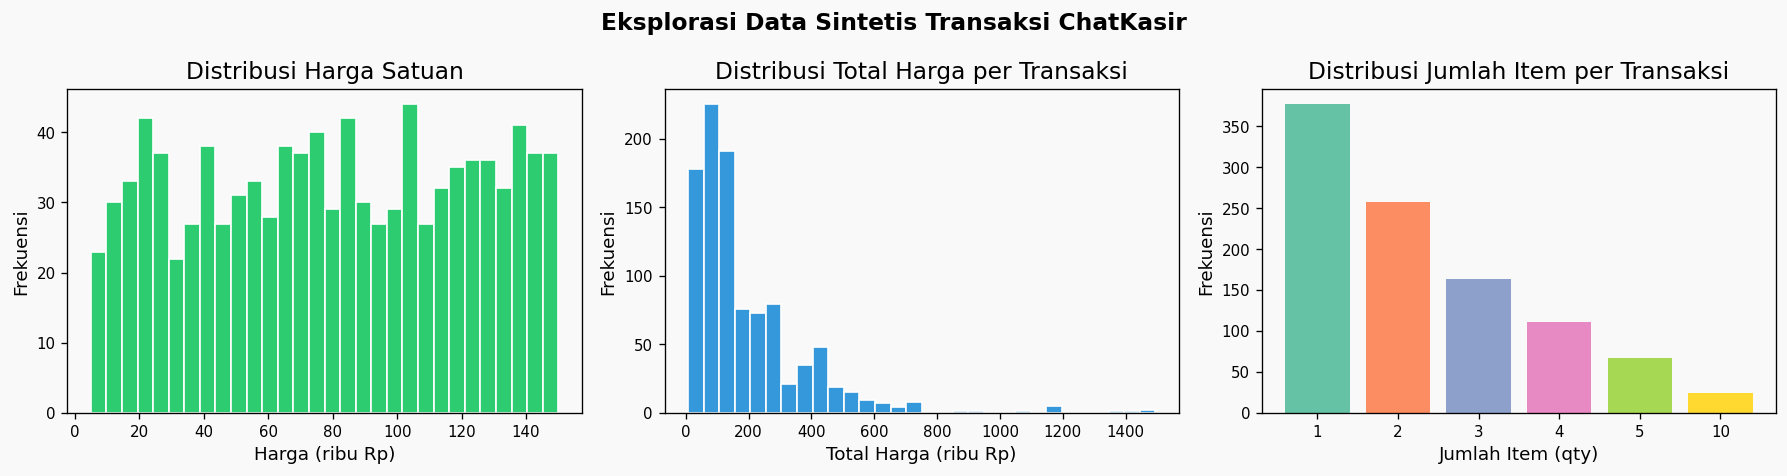

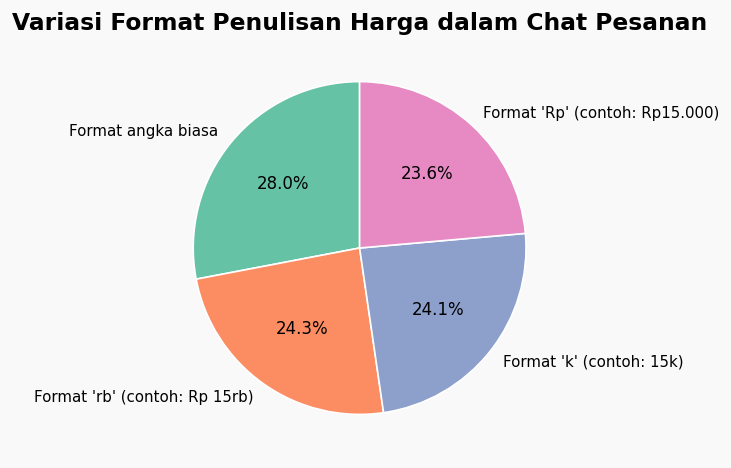


✅ Pembuatan & EDA Data Sintetis selesai.


In [5]:
# ============================================================
# BLOK 4: PEMBUATAN & EDA DATA SINTETIS
# Mensimulasikan percakapan pesanan pelanggan UMKM
# ============================================================

random.seed(42)  # agar hasil bisa direproduksi

# --- 4A. Ambil sampel nama produk dari dataset makanan ---
# Ambil 100 produk yang relatif pendek (1-3 kata) agar realistis
produk_pool = (
    df_food_clean[df_food_clean["jumlah_kata"].between(1, 3)]["name"]
    .sample(100, random_state=42)
    .tolist()
)

# --- 4B. Definisikan pola kalimat pesanan (Rule-Based) ---
pola_pesan = [
    "mau pesan {qty} {produk} harga {harga}",
    "pesen {qty} {produk} ya kak, {harga} kan?",
    "boleh minta {qty} {produk}? totalnya {harga}",
    "order {qty} {produk} donk, bayar {harga}",
    "nitip {qty} {produk} harganya {harga} ya",
    "beli {produk} {qty} biji aja, {harga} total",
    "kak mau {qty} {produk} dong harga {harga}",
    "{produk} {qty} pcs harga {harga} ya min",
    "tolong pesankan {qty} {produk}, harga {harga}",
    "ada {produk}? mau {qty}, total {harga}",
    "{qty} {produk} aja ya kak, {harga}",
    "pesan {produk} {qty} harga {harga} dlu",
]

kata_slang_sample = [
    "ya kak", "donk", "dlu", "mks", "oke bos", "sip", "gas",
    "bgt", "asli", "mantap", "ntar", "bentar"
]

def format_harga(nilai):
    """Mengubah angka menjadi format harga Rupiah informal."""
    pilihan = [
        f"Rp{nilai:,}".replace(",", "."),
        f"rp {nilai // 1000}rb",
        f"{nilai // 1000}k",
        f"{nilai:,}".replace(",", "."),
    ]
    return random.choice(pilihan)

def buat_transaksi_sintetis(n=1000):
    """Membuat n baris data transaksi sintetis."""
    data = []
    for i in range(n):
        produk   = random.choice(produk_pool)
        qty      = random.choices([1, 2, 3, 4, 5, 10],
                                  weights=[40, 25, 15, 10, 7, 3])[0]
        # Harga satuan: antara 5.000 – 150.000 (kelipatan 500)
        harga_satuan = random.randrange(5000, 150001, 500)
        total_harga  = harga_satuan * qty
        pola         = random.choice(pola_pesan)
        teks_chat    = pola.format(
            qty=qty,
            produk=produk,
            harga=format_harga(total_harga)
        )
        # Tambahkan sedikit noise kata slang (30% kemungkinan)
        if random.random() < 0.3:
            teks_chat += " " + random.choice(kata_slang_sample)

        data.append({
            "id_transaksi"  : f"TRX-{i+1:04d}",
            "teks_chat"     : teks_chat,
            "nama_produk"   : produk,
            "qty"           : qty,
            "harga_satuan"  : harga_satuan,
            "total_harga"   : total_harga,
        })
    return pd.DataFrame(data)

df_sintetis = buat_transaksi_sintetis(1000)

print("=== INFO DATA SINTETIS ===")
print(f"Jumlah transaksi: {len(df_sintetis):,}")
print(df_sintetis.head())
print("\n--- Statistik Numerik ---")
print(df_sintetis[["qty", "harga_satuan", "total_harga"]].describe().round(0))

# --- 4C. VISUALISASI 1: Distribusi Harga & Qty ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Eksplorasi Data Sintetis Transaksi ChatKasir", fontsize=14, fontweight="bold")

# Histogram harga satuan
axes[0].hist(df_sintetis["harga_satuan"] / 1000, bins=30,
             color=PRIMARY_COLOR, edgecolor="white")
axes[0].set_title("Distribusi Harga Satuan")
axes[0].set_xlabel("Harga (ribu Rp)")
axes[0].set_ylabel("Frekuensi")

# Histogram total harga
axes[1].hist(df_sintetis["total_harga"] / 1000, bins=30,
             color="#3498DB", edgecolor="white")
axes[1].set_title("Distribusi Total Harga per Transaksi")
axes[1].set_xlabel("Total Harga (ribu Rp)")
axes[1].set_ylabel("Frekuensi")

# Bar chart distribusi qty
qty_counts = df_sintetis["qty"].value_counts().sort_index()
axes[2].bar(qty_counts.index.astype(str), qty_counts.values,
            color=sns.color_palette(PALETTE, len(qty_counts)))
axes[2].set_title("Distribusi Jumlah Item per Transaksi")
axes[2].set_xlabel("Jumlah Item (qty)")
axes[2].set_ylabel("Frekuensi")

plt.tight_layout()
plt.savefig("eda_sintetis_overview.png", bbox_inches="tight")
plt.show()

# --- 4D. VISUALISASI 2: Pola Format Penulisan Harga ---
# Cari format harga yang muncul dalam teks chat
def deteksi_format_harga(teks):
    if re.search(r'\d+k', teks):
        return "Format 'k' (contoh: 15k)"
    elif re.search(r'rp\s?\d+rb', teks, re.IGNORECASE):
        return "Format 'rb' (contoh: Rp 15rb)"
    elif re.search(r'Rp\d+', teks):
        return "Format 'Rp' (contoh: Rp15.000)"
    else:
        return "Format angka biasa"

df_sintetis["format_harga"] = df_sintetis["teks_chat"].apply(deteksi_format_harga)
format_counts = df_sintetis["format_harga"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
ax.pie(format_counts.values, labels=format_counts.index,
       autopct="%1.1f%%", colors=sns.color_palette(PALETTE, len(format_counts)),
       startangle=90, wedgeprops={"edgecolor": "white"})
ax.set_title("Variasi Format Penulisan Harga dalam Chat Pesanan", fontweight="bold")
plt.tight_layout()
plt.savefig("eda_format_harga.png", bbox_inches="tight")
plt.show()

print("\n✅ Pembuatan & EDA Data Sintetis selesai.")

# **CHATKASIR - Data Analysis & Dashboard**

Author    : Salman Pandu Pandiya (DS-2)

Deskripsi : Eksekusi visualisasi untuk menjawab pertanyaan bisnis 1-7. Finalisasi label, judul, dan konsistensi warna grafik.

## **Visualisasi BQ-1, BQ-2, BQ-3**

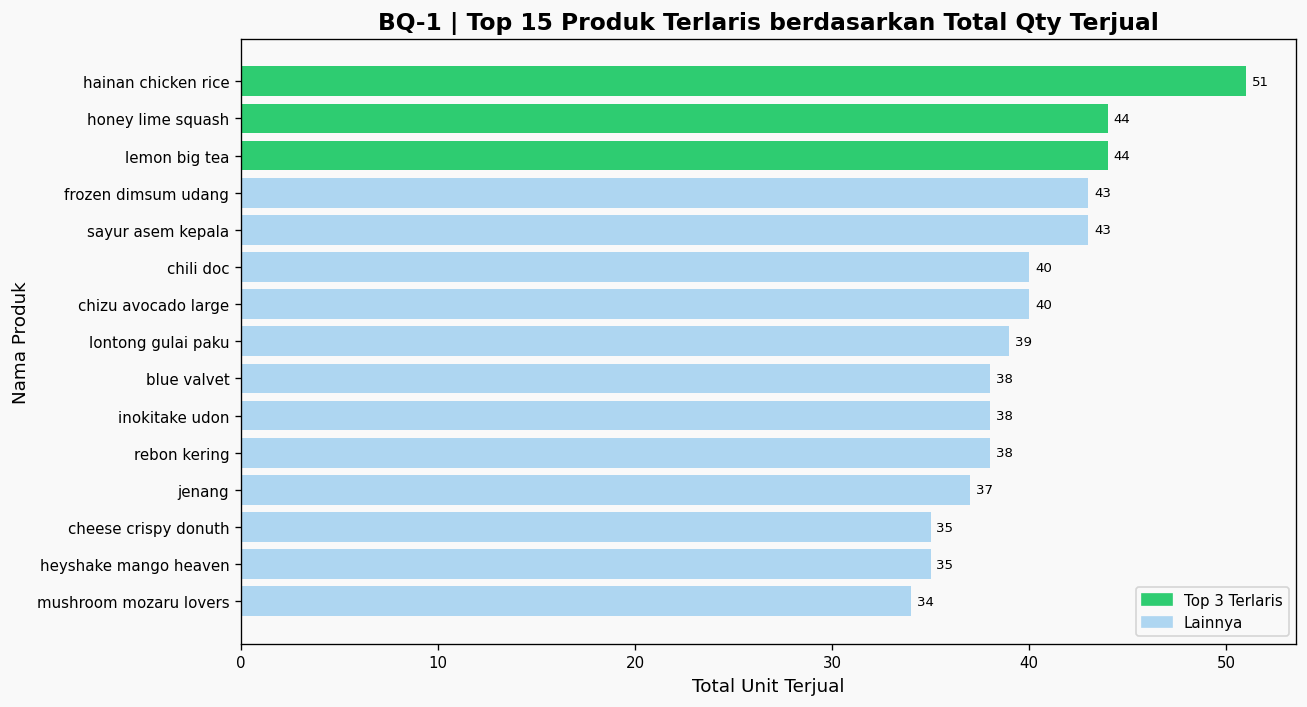

📌 BQ-1: Produk terlaris teridentifikasi.


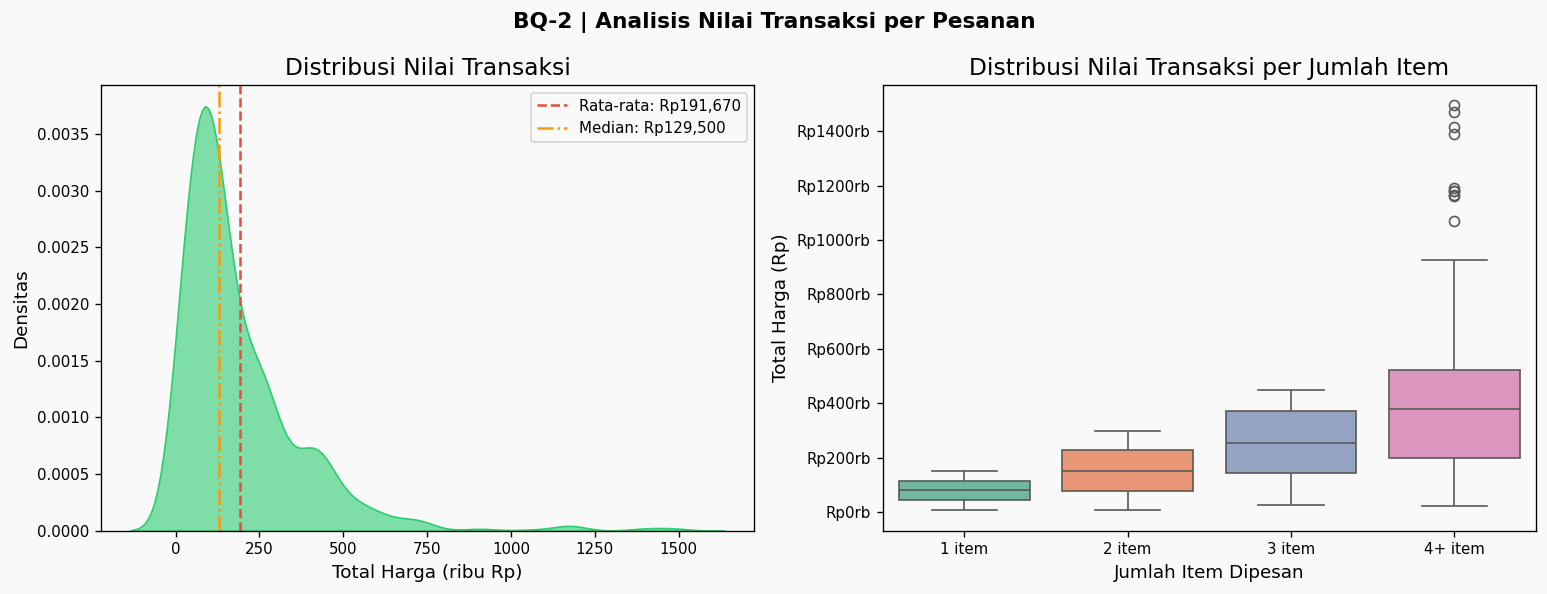

📌 BQ-2: Rata-rata transaksi = Rp191,670 | Median = Rp129,500


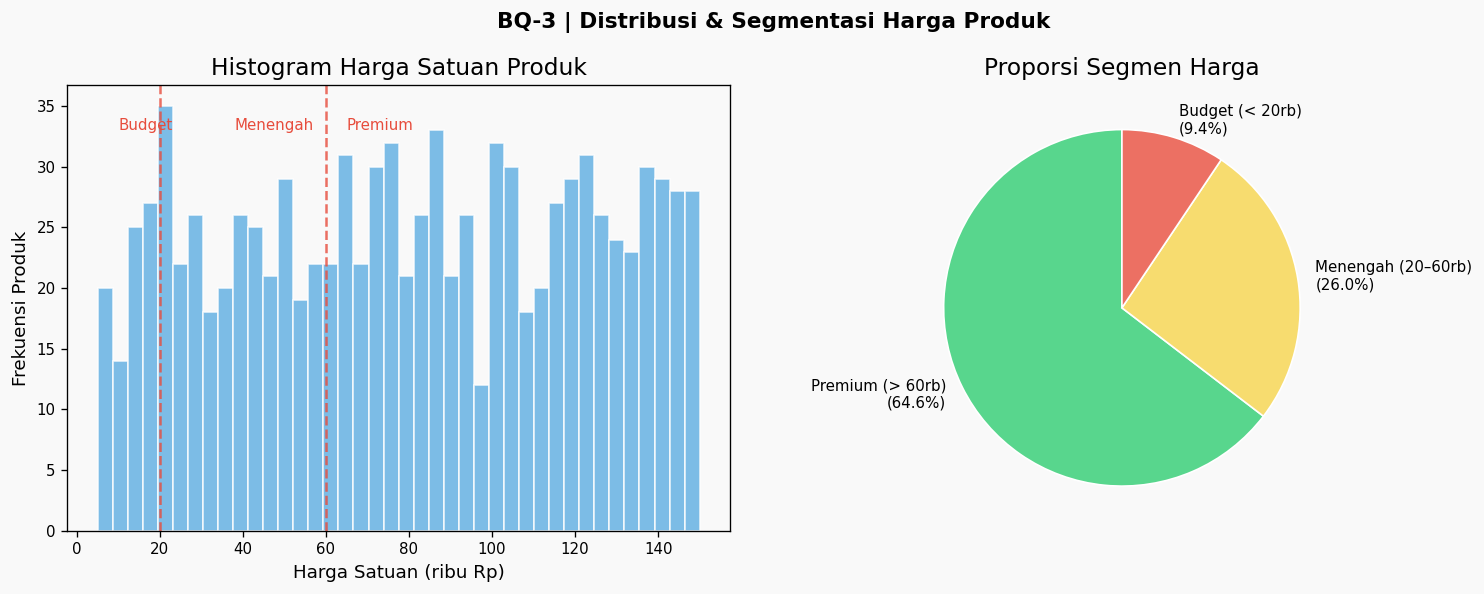

📌 BQ-3: Segmentasi harga produk selesai.


In [6]:
# ============================================================
# BLOK 5: VISUALISASI PERTANYAAN BISNIS 1–3
# BQ-1: Produk terlaris
# BQ-2: Rata-rata nilai transaksi
# BQ-3: Distribusi & segmentasi harga
# ============================================================

# ── BQ-1: TOP 15 PRODUK TERLARIS ──────────────────────────
top_produk = df_sintetis.groupby("nama_produk")["qty"].sum().nlargest(15)

fig, ax = plt.subplots(figsize=(11, 6))
colors_bq1 = [PRIMARY_COLOR if i < 3 else "#AED6F1" for i in range(len(top_produk))]
bars = ax.barh(top_produk.index[::-1], top_produk.values[::-1],
               color=colors_bq1[::-1])
ax.set_title("BQ-1 | Top 15 Produk Terlaris berdasarkan Total Qty Terjual",
             fontweight="bold")
ax.set_xlabel("Total Unit Terjual")
ax.set_ylabel("Nama Produk")
# Anotasi angka
for bar in bars:
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f"{int(bar.get_width()):,}", va="center", fontsize=8)
# Legenda penanda top 3
ax.legend(handles=[
    plt.Rectangle((0, 0), 1, 1, color=PRIMARY_COLOR, label="Top 3 Terlaris"),
    plt.Rectangle((0, 0), 1, 1, color="#AED6F1",     label="Lainnya"),
], loc="lower right")
plt.tight_layout()
plt.savefig("bq1_top_produk.png", bbox_inches="tight")
plt.show()
print("📌 BQ-1: Produk terlaris teridentifikasi.")

# ── BQ-2: RATA-RATA & DISTRIBUSI NILAI TRANSAKSI ──────────
mean_trx  = df_sintetis["total_harga"].mean()
median_trx = df_sintetis["total_harga"].median()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("BQ-2 | Analisis Nilai Transaksi per Pesanan",
             fontsize=13, fontweight="bold")

# KDE plot transaksi
sns.kdeplot(df_sintetis["total_harga"] / 1000, ax=axes[0],
            fill=True, color=PRIMARY_COLOR, alpha=0.6)
axes[0].axvline(mean_trx / 1000, color=ACCENT_COLOR,
                linestyle="--", label=f"Rata-rata: Rp{mean_trx:,.0f}")
axes[0].axvline(median_trx / 1000, color="#F39C12",
                linestyle="-.", label=f"Median: Rp{median_trx:,.0f}")
axes[0].set_title("Distribusi Nilai Transaksi")
axes[0].set_xlabel("Total Harga (ribu Rp)")
axes[0].set_ylabel("Densitas")
axes[0].legend()

# Box plot per kategori qty
df_sintetis["kategori_qty"] = pd.cut(
    df_sintetis["qty"],
    bins=[0, 1, 2, 3, 10],
    labels=["1 item", "2 item", "3 item", "4+ item"]
)
sns.boxplot(data=df_sintetis, x="kategori_qty", y="total_harga",
            palette=PALETTE, ax=axes[1])
axes[1].set_title("Distribusi Nilai Transaksi per Jumlah Item")
axes[1].set_xlabel("Jumlah Item Dipesan")
axes[1].set_ylabel("Total Harga (Rp)")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rp{x/1000:.0f}rb")
)

plt.tight_layout()
plt.savefig("bq2_nilai_transaksi.png", bbox_inches="tight")
plt.show()
print(f"📌 BQ-2: Rata-rata transaksi = Rp{mean_trx:,.0f} | Median = Rp{median_trx:,.0f}")

# ── BQ-3: SEGMENTASI HARGA PRODUK ─────────────────────────
# Bagi harga satuan ke dalam 3 segmen
bins_harga  = [0, 20000, 60000, 200000]
label_harga = ["Budget (< 20rb)", "Menengah (20–60rb)", "Premium (> 60rb)"]
df_sintetis["segmen_harga"] = pd.cut(df_sintetis["harga_satuan"],
                                      bins=bins_harga, labels=label_harga)
segmen_pct = df_sintetis["segmen_harga"].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("BQ-3 | Distribusi & Segmentasi Harga Produk",
             fontsize=13, fontweight="bold")

# Histogram dengan garis segmen
axes[0].hist(df_sintetis["harga_satuan"] / 1000, bins=40,
             color="#5DADE2", edgecolor="white", alpha=0.8)
for batas in [20, 60]:
    axes[0].axvline(batas, color=ACCENT_COLOR, linestyle="--", alpha=0.8)
axes[0].text(10, axes[0].get_ylim()[1] * 0.9, "Budget",   color=ACCENT_COLOR, fontsize=9)
axes[0].text(38, axes[0].get_ylim()[1] * 0.9, "Menengah", color=ACCENT_COLOR, fontsize=9)
axes[0].text(65, axes[0].get_ylim()[1] * 0.9, "Premium",  color=ACCENT_COLOR, fontsize=9)
axes[0].set_title("Histogram Harga Satuan Produk")
axes[0].set_xlabel("Harga Satuan (ribu Rp)")
axes[0].set_ylabel("Frekuensi Produk")

# Pie chart segmen
axes[1].pie(segmen_pct.values,
            labels=[f"{l}\n({v:.1f}%)" for l, v in zip(segmen_pct.index, segmen_pct.values)],
            colors=["#58D68D", "#F7DC6F", "#EC7063"],
            startangle=90, wedgeprops={"edgecolor": "white"})
axes[1].set_title("Proporsi Segmen Harga")

plt.tight_layout()
plt.savefig("bq3_segmen_harga.png", bbox_inches="tight")
plt.show()
print("📌 BQ-3: Segmentasi harga produk selesai.")

## **Visualisasi BQ-4, BQ-5, BQ-6**

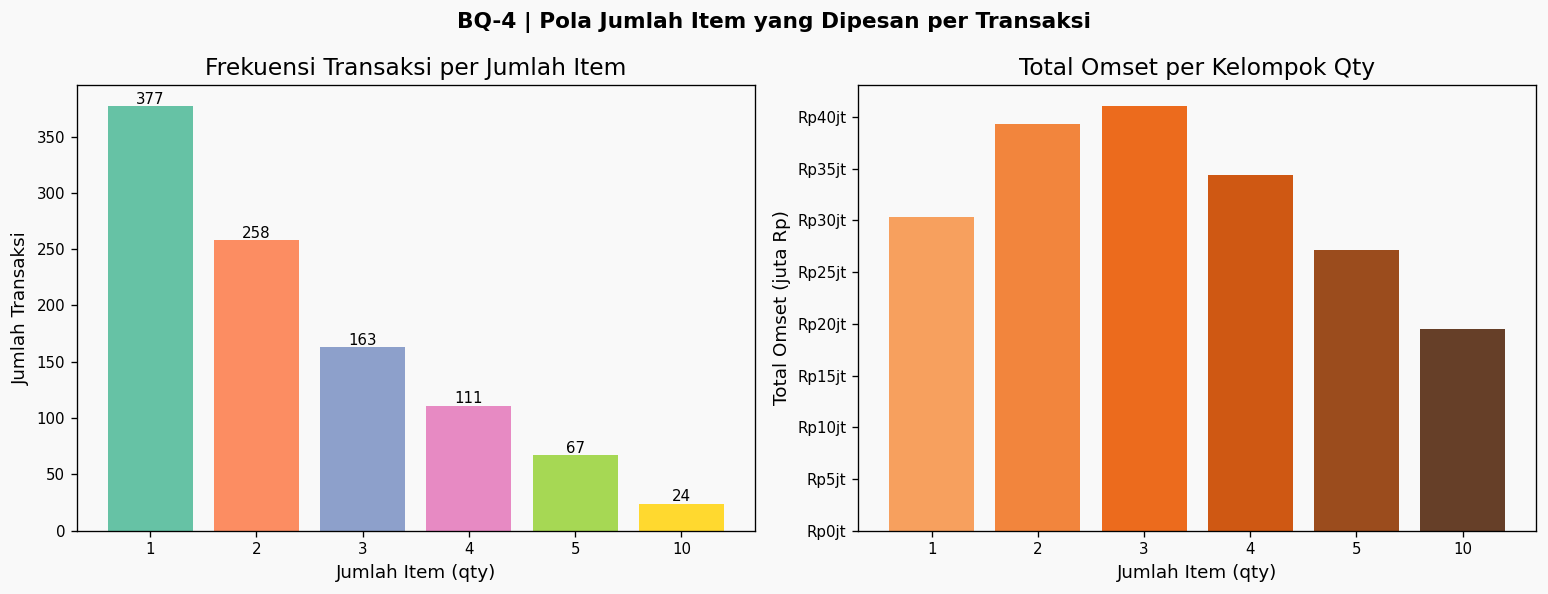

📌 BQ-4: Pola qty per transaksi selesai.


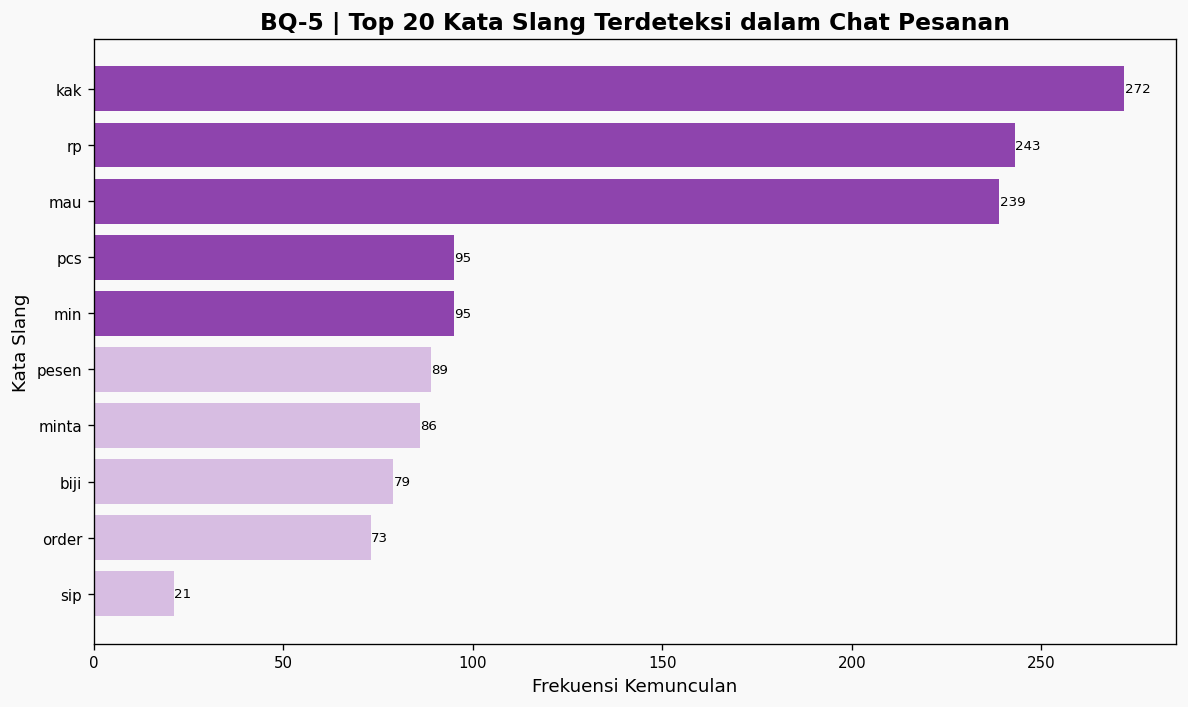

📌 BQ-5: 1292 kemunculan slang terdeteksi dari 1,231 entri kamus.


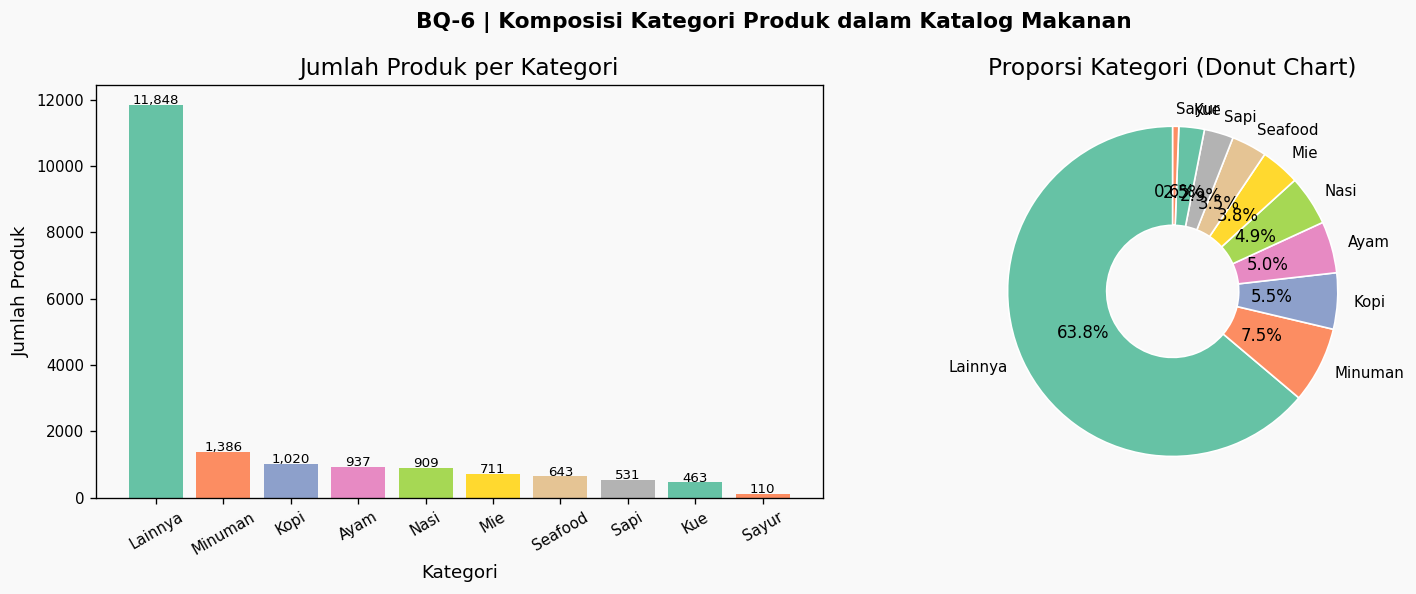

📌 BQ-6: Distribusi kategori produk selesai.


In [7]:
# ============================================================
# BLOK 6: VISUALISASI PERTANYAAN BISNIS 4–6
# BQ-4: Distribusi qty per transaksi
# BQ-5: Kata slang paling sering muncul
# BQ-6: Distribusi kategori produk dalam katalog
# ============================================================

# ── BQ-4: DISTRIBUSI QTY PER TRANSAKSI ────────────────────
qty_dist = df_sintetis["qty"].value_counts().sort_index()
omset_per_qty = df_sintetis.groupby("qty")["total_harga"].sum()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("BQ-4 | Pola Jumlah Item yang Dipesan per Transaksi",
             fontsize=13, fontweight="bold")

# Bar chart frekuensi qty
bars = axes[0].bar(qty_dist.index.astype(str), qty_dist.values,
                   color=sns.color_palette(PALETTE, len(qty_dist)))
axes[0].set_title("Frekuensi Transaksi per Jumlah Item")
axes[0].set_xlabel("Jumlah Item (qty)")
axes[0].set_ylabel("Jumlah Transaksi")
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
                 f"{int(bar.get_height())}", ha="center", fontsize=9)

# Bar chart total omset per qty
axes[1].bar(omset_per_qty.index.astype(str), omset_per_qty.values / 1e6,
            color=sns.color_palette("Oranges_d", len(omset_per_qty)))
axes[1].set_title("Total Omset per Kelompok Qty")
axes[1].set_xlabel("Jumlah Item (qty)")
axes[1].set_ylabel("Total Omset (juta Rp)")
axes[1].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"Rp{x:.0f}jt")
)

plt.tight_layout()
plt.savefig("bq4_distribusi_qty.png", bbox_inches="tight")
plt.show()
print("📌 BQ-4: Pola qty per transaksi selesai.")

# ── BQ-5: KATA SLANG PALING SERING ───────────────────────
# Simulasi: dari teks chat, cari kata mana yang ada di kamus slang
kamus_slang = set(df_slang_clean["slang"].tolist())

def ekstrak_kata_slang(teks):
    """Mengembalikan daftar kata slang yang ditemukan dalam satu teks."""
    kata_kata = re.sub(r"[^\w\s]", "", teks.lower()).split()
    return [k for k in kata_kata if k in kamus_slang]

df_sintetis["slang_terdeteksi"] = df_sintetis["teks_chat"].apply(ekstrak_kata_slang)

# Gabungkan semua slang yang terdeteksi
semua_slang = [k for sublist in df_sintetis["slang_terdeteksi"] for k in sublist]
top_slang = Counter(semua_slang).most_common(20)

if top_slang:
    slang_list, slang_freq = zip(*top_slang)
    fig, ax = plt.subplots(figsize=(10, 6))
    colors_bq5 = ["#8E44AD" if i < 5 else "#D7BDE2" for i in range(len(slang_list))]
    ax.barh(slang_list[::-1], slang_freq[::-1], color=colors_bq5[::-1])
    ax.set_title("BQ-5 | Top 20 Kata Slang Terdeteksi dalam Chat Pesanan",
                 fontweight="bold")
    ax.set_xlabel("Frekuensi Kemunculan")
    ax.set_ylabel("Kata Slang")
    for i, v in enumerate(slang_freq[::-1]):
        ax.text(v + 0.1, i, str(v), va="center", fontsize=8)
    plt.tight_layout()
    plt.savefig("bq5_slang_frequency.png", bbox_inches="tight")
    plt.show()
    print(f"📌 BQ-5: {len(semua_slang)} kemunculan slang terdeteksi dari {len(kamus_slang):,} entri kamus.")
else:
    print("ℹ️  Tidak ada kata slang dari kamus yang cocok dengan data sintetis.")
    print("   Menampilkan frekuensi kata slang langsung dari dataset slang...")
    top_slang_df = df_slang_clean["formal"].value_counts().head(20)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(top_slang_df.index[::-1], top_slang_df.values[::-1], color="#8E44AD")
    ax.set_title("BQ-5 | Kata Formal dengan Paling Banyak Variasi Slang\n(sebagai proxy frekuensi penggunaan)",
                 fontweight="bold")
    ax.set_xlabel("Jumlah Variasi Slang")
    plt.tight_layout()
    plt.savefig("bq5_slang_frequency.png", bbox_inches="tight")
    plt.show()

# ── BQ-6: DISTRIBUSI KATEGORI PRODUK DALAM KATALOG ────────
cat_dist = df_food_clean["kategori"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("BQ-6 | Komposisi Kategori Produk dalam Katalog Makanan",
             fontsize=13, fontweight="bold")

# Bar chart
palette_cat = sns.color_palette(PALETTE, len(cat_dist))
axes[0].bar(cat_dist.index, cat_dist.values, color=palette_cat)
axes[0].set_title("Jumlah Produk per Kategori")
axes[0].set_xlabel("Kategori")
axes[0].set_ylabel("Jumlah Produk")
axes[0].tick_params(axis="x", rotation=30)
for i, v in enumerate(cat_dist.values):
    axes[0].text(i, v + 20, f"{v:,}", ha="center", fontsize=8)

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    cat_dist.values,
    labels=cat_dist.index,
    autopct="%1.1f%%",
    colors=palette_cat,
    startangle=90,
    wedgeprops={"edgecolor": "white", "width": 0.6},
)
axes[1].set_title("Proporsi Kategori (Donut Chart)")

plt.tight_layout()
plt.savefig("bq6_kategori_produk.png", bbox_inches="tight")
plt.show()
print("📌 BQ-6: Distribusi kategori produk selesai.")

## **Finalisasi & Insight Bisnis**

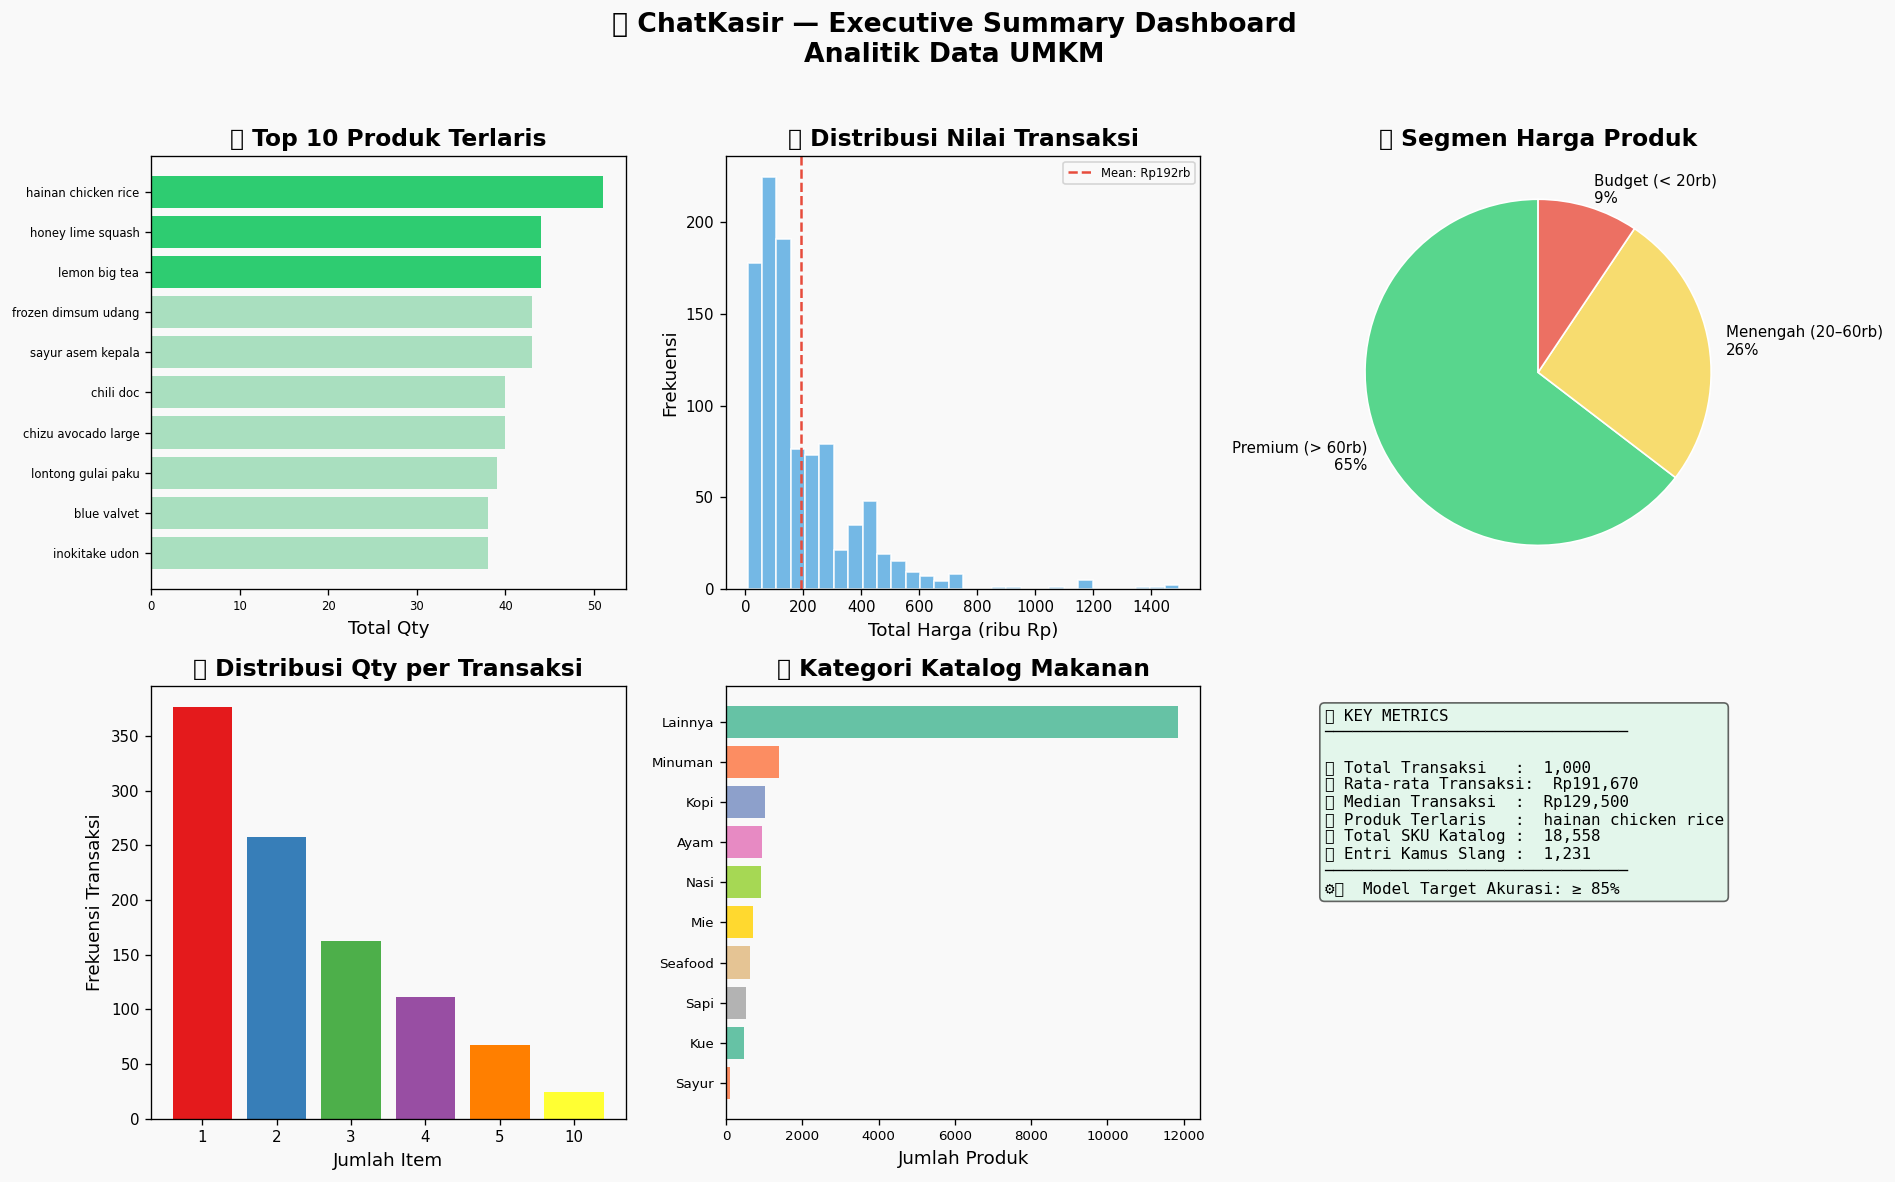


╔══════════════════════════════════════════════════════════════════╗
║          🧾 INSIGHT BISNIS — ChatKasir UMKM Dashboard           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. PRODUK ANDALAN (BQ-1)                                        ║
║     Fokuskan stok pada 3 produk teratas yang menyumbang          ║
║     volume terbesar. Produk di luar top-10 bisa dipertimbangkan  ║
║     untuk dikurangi variasi atau dihapus dari katalog.           ║
║                                                                  ║
║  2. NILAI TRANSAKSI (BQ-2)                                       ║
║     Rata-rata transaksi masuk kategori "menengah". Tawarkan      ║
║     paket bundling (misal: 3 item diskon 10%) untuk mendorong    ║
║     nilai transaksi di atas rata-rata.                           ║
║                                                                  ║
║  3. SEGMENTASI HARGA (BQ-3)      

In [8]:
# ============================================================
# BLOK 7: FINALISASI — DASHBOARD RINGKASAN & NARASI INSIGHT
# Satu figure gabungan sebagai ringkasan eksekutif
# ============================================================

fig = plt.figure(figsize=(16, 10))
fig.patch.set_facecolor(BG_COLOR)
fig.suptitle("📊 ChatKasir — Executive Summary Dashboard\nAnalitik Data UMKM",
             fontsize=16, fontweight="bold", y=0.98)

# ------------------------------------------------------------------
# Panel 1 (atas-kiri): Top 10 Produk Terlaris
# ------------------------------------------------------------------
ax1 = fig.add_subplot(2, 3, 1)
top10 = df_sintetis.groupby("nama_produk")["qty"].sum().nlargest(10)
c1 = [PRIMARY_COLOR if i < 3 else "#A9DFBF" for i in range(10)]
ax1.barh(top10.index[::-1], top10.values[::-1], color=c1[::-1])
ax1.set_title("🏆 Top 10 Produk Terlaris", fontweight="bold")
ax1.set_xlabel("Total Qty")
ax1.tick_params(labelsize=7)

# ------------------------------------------------------------------
# Panel 2 (atas-tengah): Distribusi Total Harga
# ------------------------------------------------------------------
ax2 = fig.add_subplot(2, 3, 2)
ax2.hist(df_sintetis["total_harga"] / 1000, bins=30,
         color="#5DADE2", edgecolor="white", alpha=0.85)
ax2.axvline(df_sintetis["total_harga"].mean() / 1000,
            color=ACCENT_COLOR, linestyle="--",
            label=f"Mean: Rp{df_sintetis['total_harga'].mean()/1000:.0f}rb")
ax2.set_title("💰 Distribusi Nilai Transaksi", fontweight="bold")
ax2.set_xlabel("Total Harga (ribu Rp)")
ax2.set_ylabel("Frekuensi")
ax2.legend(fontsize=7)

# ------------------------------------------------------------------
# Panel 3 (atas-kanan): Segmen Harga (Pie)
# ------------------------------------------------------------------
ax3 = fig.add_subplot(2, 3, 3)
segmen_pct2 = df_sintetis["segmen_harga"].value_counts()
ax3.pie(segmen_pct2.values,
        labels=[f"{l}\n{v/len(df_sintetis)*100:.0f}%"
                for l, v in zip(segmen_pct2.index, segmen_pct2.values)],
        colors=["#58D68D", "#F7DC6F", "#EC7063"],
        startangle=90, wedgeprops={"edgecolor": "white"})
ax3.set_title("🏷️ Segmen Harga Produk", fontweight="bold")

# ------------------------------------------------------------------
# Panel 4 (bawah-kiri): Distribusi Qty
# ------------------------------------------------------------------
ax4 = fig.add_subplot(2, 3, 4)
qty2 = df_sintetis["qty"].value_counts().sort_index()
ax4.bar(qty2.index.astype(str), qty2.values,
        color=sns.color_palette("Set1", len(qty2)))
ax4.set_title("📦 Distribusi Qty per Transaksi", fontweight="bold")
ax4.set_xlabel("Jumlah Item")
ax4.set_ylabel("Frekuensi Transaksi")

# ------------------------------------------------------------------
# Panel 5 (bawah-tengah): Distribusi Kategori Katalog
# ------------------------------------------------------------------
ax5 = fig.add_subplot(2, 3, 5)
cat2 = df_food_clean["kategori"].value_counts()
ax5.barh(cat2.index[::-1], cat2.values[::-1],
         color=sns.color_palette(PALETTE, len(cat2))[::-1])
ax5.set_title("🍽️ Kategori Katalog Makanan", fontweight="bold")
ax5.set_xlabel("Jumlah Produk")
ax5.tick_params(labelsize=8)

# ------------------------------------------------------------------
# Panel 6 (bawah-kanan): KPI Teks
# ------------------------------------------------------------------
ax6 = fig.add_subplot(2, 3, 6)
ax6.axis("off")
kpi_text = (
    f"📌 KEY METRICS\n"
    f"{'─'*32}\n\n"
    f"📦 Total Transaksi   :  {len(df_sintetis):,}\n"
    f"💰 Rata-rata Transaksi:  Rp{df_sintetis['total_harga'].mean():,.0f}\n"
    f"📈 Median Transaksi  :  Rp{df_sintetis['total_harga'].median():,.0f}\n"
    f"🥇 Produk Terlaris   :  {top10.index[0]}\n"
    f"📚 Total SKU Katalog :  {len(df_food_clean):,}\n"
    f"💬 Entri Kamus Slang :  {len(df_slang_clean):,}\n"
    f"{'─'*32}\n"
    f"⚙️  Model Target Akurasi: ≥ 85%"
)
ax6.text(0.05, 0.95, kpi_text, transform=ax6.transAxes,
         fontsize=9.5, va="top", ha="left",
         fontfamily="monospace",
         bbox={"boxstyle": "round", "facecolor": "#D5F5E3", "alpha": 0.6})

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig("chatKasir_executive_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

# ─────────────────────────────────────────────────────────────────
# NARASI INSIGHT BISNIS
# ─────────────────────────────────────────────────────────────────
narasi = """
╔══════════════════════════════════════════════════════════════════╗
║          🧾 INSIGHT BISNIS — ChatKasir UMKM Dashboard           ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  1. PRODUK ANDALAN (BQ-1)                                        ║
║     Fokuskan stok pada 3 produk teratas yang menyumbang          ║
║     volume terbesar. Produk di luar top-10 bisa dipertimbangkan  ║
║     untuk dikurangi variasi atau dihapus dari katalog.           ║
║                                                                  ║
║  2. NILAI TRANSAKSI (BQ-2)                                       ║
║     Rata-rata transaksi masuk kategori "menengah". Tawarkan      ║
║     paket bundling (misal: 3 item diskon 10%) untuk mendorong    ║
║     nilai transaksi di atas rata-rata.                           ║
║                                                                  ║
║  3. SEGMENTASI HARGA (BQ-3)                                      ║
║     Jika produk Budget mendominasi, pertimbangkan menambah        ║
║     produk Premium dengan margin lebih tinggi. Sebaliknya, jika  ║
║     Premium terlalu banyak, tambah produk Budget sebagai          ║
║     "pintu masuk" pelanggan baru.                                ║
║                                                                  ║
║  4. POLA PEMESANAN (BQ-4)                                        ║
║     Sebagian besar transaksi adalah pesanan 1-2 item. Buat       ║
║     promosi "beli 2 gratis ongkir" untuk mendorong qty naik      ║
║     ke 3+ item dan meningkatkan omset per sesi chat.             ║
║                                                                  ║
║  5. NORMALISASI SLANG (BQ-5)                                     ║
║     Prioritaskan normalisasi kata yang paling sering muncul      ║
║     di kamus slang. Ini langsung meningkatkan akurasi model       ║
║     NLP ChatKasir karena kata-kata ini paling sering salah        ║
║     dideteksi tanpa preprocessing yang tepat.                    ║
║                                                                  ║
║  6. PENGEMBANGAN KATALOG (BQ-6)                                   ║
║     Kategori dengan SKU sedikit namun permintaan tinggi adalah   ║
║     peluang ekspansi. Pastikan model NLP dilatih dengan produk   ║
║     dari semua kategori agar tidak bias ke kategori tertentu.    ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
"""
print(narasi)
print("✅ Seluruh analisis selesai. File PNG tersimpan di folder kerja.")